# Notebook 2 - Equilibrium Calculations

**Reference:** Xu et al. 2025, *J. Mater. Res. Technol.* 35, 4779–4791  
**Database:** `mc_fe_v2062_clean.tdb` (MatCalc Open Steel Database v2.062 - Cleaned for pycalphad)

## Objectives

1. Phase fraction vs temperature sweep (600 K – 1400 K)
2. Isothermal calculations at 370°C and 480°C to validate against Xu et al.

## Composition

Full alloy: Fe–18Ni–8.5Co–5Mo–0.7Ti–0.2Al (wt%) — **no renormalization needed**

## 0. Imports and Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pycalphad import Database, equilibrium, variables as v

import warnings
# warnings.filterwarnings('ignore')

print(f'pycalphad version: {__import__("pycalphad").__version__}')

pycalphad version: 0.11.1


## 1. Load Database and Define Composition

In [7]:
DB_PATH = '../databases/mc_fe_v2062_clean.tdb'
db = Database(DB_PATH)

assert 'ETA' in db.phases, 'ETA (Ni3Ti) phase not found'
print('Database loaded successfully.')
print(f'Phases available: {sorted(db.phases.keys())}')

# Atomic weights
AW = {'FE': 55.845, 'NI': 58.693, 'CO': 58.933, 'MO': 95.94, 'TI': 47.867, 'AL': 26.982}

# Weight fractions
wt_frac = {'NI': 0.180, 'CO': 0.085, 'MO': 0.050, 'TI': 0.007, 'AL': 0.002}
wt_frac['FE'] = 1.0 - sum(wt_frac.values())

# Convert to mole fractions
moles = {el: wt_frac[el] / AW[el] for el in AW}
total_moles = sum(moles.values())
comp = {el: moles[el] / total_moles for el in moles}

print(f'\nComposition (mole fractions):')
for el, xf in comp.items():
    print(f'  X({el}) = {xf:.5f}')

# Components and phases
COMPONENTS = ['FE', 'NI', 'CO', 'MO', 'TI', 'AL', 'VA']
PHASES = [p for p in ['LIQUID', 'BCC_A2', 'FCC_A1', 'HCP_A3', 'ETA',
          'LAVES_PHASE', 'BCC_B2', 'NITI2', 'SIGMA', 'MU_PHASE']
          if p in db.phases]
print(f'\nPhases to compute: {PHASES}')

Database loaded successfully.
Phases available: ['ALN', 'ALN_EQU', 'ALPHA_MN', 'ANILITE', 'A_CHALC', 'BCC_A2', 'BCC_B2', 'BCC_DISL', 'BETA_MN', 'BETA_RHOMBO_B', 'BN_HP4', 'B_CHALC', 'C15_LAVES', 'CEMENTITE', 'CHI_A12', 'CO3MO', 'CO3V', 'CORUND', 'COV3', 'COVELLITE', 'CR2B', 'CR2VC2', 'CR3MN5', 'CR5B3', 'CRB', 'CU2S', 'DIAMOND_A4', 'DIGENITE', 'DISULF', 'DJURLEITE', 'EPS_CARB', 'ETA', 'ETA_CARB', 'FCC_A1', 'FC_MONO', 'FE17Y2', 'FE24C10', 'FE3NB3B4', 'FE4N', 'FEB', 'FENBB', 'FES_P', 'GAMMA_PRIME', 'GRAPHITE', 'G_PHASE', 'HALITE', 'HCP_A3', 'HF1O2_C', 'HF1O2_M', 'HF1O2_T', 'H_BCC', 'KSI_CARBIDE', 'KSI_FE5C2', 'K_CARB', 'LA2O3_A', 'LA2O3_C', 'LA2O3_H', 'LAVES_PHASE', 'LIQUID', 'M12C', 'M23C6', 'M2B', 'M2P', 'M3C2', 'M3P', 'M5B6', 'M6C', 'M7C3', 'MN3B4', 'MN6N4', 'MN6N5', 'MNB2', 'MNB4', 'MNNI', 'MNNI2', 'MNSIN2', 'MNS_Q', 'MO2M1B2', 'MOB', 'MOB2', 'MOC_ETA', 'MU_PHASE', 'MU_PHASE_I', 'NB3B2', 'NBB', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'NI5Y', 'NISI', 'NITI2', 'O1_GA

/run/media/adi/New Volume/conda-envs/struct/lib/python3.11/site-packages/pycalphad/io/tdb.py:995: UserWarning: The type definition character `%` was defined in the following phases: ['LIQUID', 'FCC_A1', 'BCC_A2', 'H_BCC', 'HCP_A3', 'ALPHA_MN', 'BETA_MN', 'BETA_RHOMBO_B', 'DIAMOND_A4', 'GRAPHITE', 'BCC_B2', 'NISI', 'CHI_A12', 'CO3MO', 'CO3V', 'COV3', 'CR3MN5', 'G_PHASE', 'C15_LAVES', 'GAMMA_PRIME', 'LAVES_PHASE', 'MNNI', 'MNNI2', 'T2_MNNISI', 'T4', 'T7', 'MU_PHASE', 'MU_PHASE_I', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'ETA', 'NITI2', 'PI_PHASE', 'R_PHASE', 'SIGMA', 'FE17Y2', 'NI5Y', 'PDFE_L12', 'PDMN_AF', 'PDMN_P', 'PDMN_B2', 'PD2MN', 'PD3MN', 'PD5MN3', 'PD6FE5MN2', 'CEMENTITE', 'CR2VC2', 'K_CARB', 'KSI_CARBIDE', 'M3C2', 'M6C', 'M7C3', 'M12C', 'M23C6', 'MOC_ETA', 'V3C2', 'WC', 'EPS_CARB', 'ETA_CARB', 'FE24C10', 'KSI_FE5C2', 'ALN', 'ALN_EQU', 'BN_HP4', 'FE4N', 'MN6N4', 'MN6N5', 'MNSIN2', 'SI3N4', 'TAN_EPS', 'ZET', 'CRB', 'CR2B', 'CR5B3', 'FEB', 'FENBB', 'FE3NB3B4', '

## Step 1 — Phase Fraction vs Temperature (600 K – 1400 K)

In [8]:
T_MIN, T_MAX, T_STEP = 600, 1400, 10
T_range = np.arange(T_MIN, T_MAX + T_STEP, T_STEP)

print('Running equilibrium sweep... (this may take several minutes with 6 components)')

result_sweep = equilibrium(
    db, COMPONENTS, PHASES,
    {v.X('NI'): comp['NI'], v.X('CO'): comp['CO'], v.X('MO'): comp['MO'],
     v.X('TI'): comp['TI'], v.X('AL'): comp['AL'],
     v.T: T_range, v.P: 101325}
)

print('Sweep complete.')

Running equilibrium sweep... (this may take several minutes with 6 components)
Sweep complete.


In [9]:
# --- Extract phase fractions ---
phase_fracs = {}
for ph in PHASES:
    mask = result_sweep.Phase == ph
    frac = result_sweep.NP.where(mask).sum(dim='vertex').squeeze().values
    phase_fracs[ph] = np.nan_to_num(frac, nan=0.0)

# Combine order-disorder pairs
combined = {}
combined['BCC (martensite)'] = phase_fracs.get('BCC_A2', 0) + phase_fracs.get('BCC_B2', 0)
combined['FCC (austenite)'] = phase_fracs.get('FCC_A1', 0)
for ph in ['ETA', 'LAVES_PHASE', 'NITI2', 'LIQUID', 'HCP_A3', 'SIGMA', 'MU_PHASE']:
    if ph in phase_fracs:
        combined[ph] = phase_fracs[ph]

T_C = T_range - 273.15
T_DAT1, T_DAT2, T_SST = 370, 480, 840

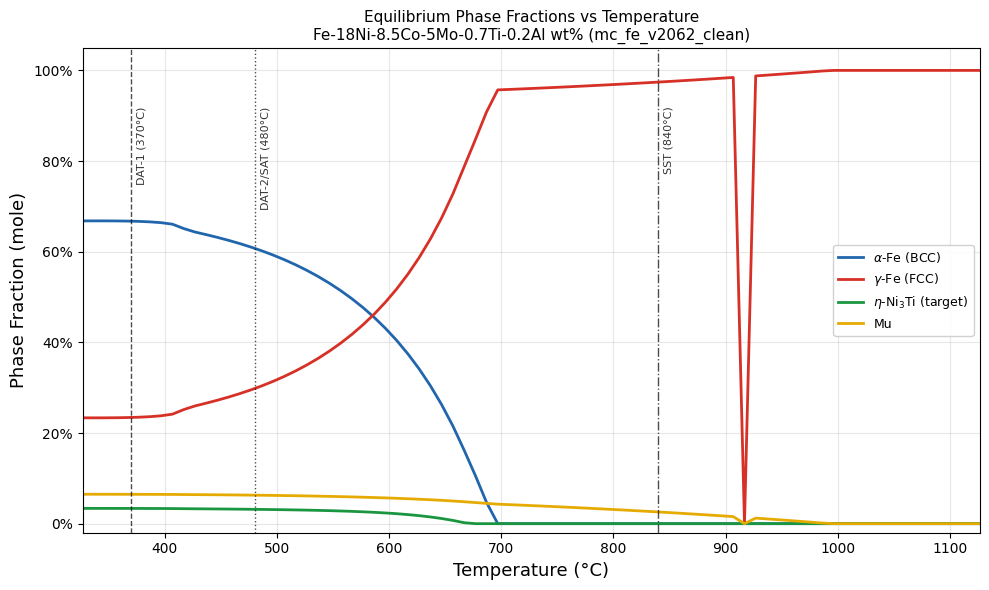

Figure saved.


In [10]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

COLORS = {'BCC (martensite)': '#2166ac', 'FCC (austenite)': '#d73027',
          'ETA': '#1a9641', 'LAVES_PHASE': '#a65628', 'LIQUID': '#984ea3',
          'HCP_A3': '#ff7f00', 'NITI2': '#e7298a', 'SIGMA': '#66a61e', 'MU_PHASE': '#e6ab02'}
LABELS = {'BCC (martensite)': r'$\alpha$-Fe (BCC)', 'FCC (austenite)': r'$\gamma$-Fe (FCC)',
          'ETA': r'$\eta$-Ni$_3$Ti (target)', 'LAVES_PHASE': 'Laves',
          'LIQUID': 'Liquid', 'HCP_A3': 'HCP', 'NITI2': 'NiTi$_2$',
          'SIGMA': 'Sigma', 'MU_PHASE': 'Mu'}

for ph, frac in combined.items():
    if isinstance(frac, (int, float)):
        continue
    if frac.max() > 0.001:
        ax.plot(T_C, frac, color=COLORS.get(ph, 'grey'), label=LABELS.get(ph, ph), linewidth=2)

for T_mark, label, style in [(T_DAT1,'DAT-1 (370°C)','--'), (T_DAT2,'DAT-2/SAT (480°C)',':'), (T_SST,'SST (840°C)','-.')]:
    ax.axvline(T_mark, color='black', linestyle=style, linewidth=1.0, alpha=0.7)
    ax.text(T_mark+5, 0.92, label, fontsize=8, rotation=90, va='top', alpha=0.8)

ax.set_xlabel('Temperature (°C)', fontsize=13)
ax.set_ylabel('Phase Fraction (mole)', fontsize=13)
ax.set_title('Equilibrium Phase Fractions vs Temperature\nFe-18Ni-8.5Co-5Mo-0.7Ti-0.2Al wt% (mc_fe_v2062_clean)', fontsize=11)
ax.set_xlim(T_C[0], T_C[-1]); ax.set_ylim(-0.02, 1.05)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.legend(loc='center right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig1_phase_fraction_vs_T.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [ ]:
# --- Key values from sweep ---
def get_phase_frac_at_T(phase, T_celsius):
    idx = np.argmin(np.abs(T_C - T_celsius))
    return phase_fracs.get(phase, np.zeros_like(T_C))[idx]

print('=== Key Phase Fractions ===')
for T in [370, 480, 840]:
    print(f'  At {T}°C : ETA(Ni3Ti) = {get_phase_frac_at_T("ETA", T):.4f}')

eta_frac = phase_fracs.get('ETA', np.zeros_like(T_C))
solvus = T_C[eta_frac > 0.001]
if len(solvus) > 0:
    print(f'  Ni3Ti solvus (approx): {solvus.max():.0f} °C')
    print(f'  Ni3Ti stable between:  {solvus.min():.0f} °C and {solvus.max():.0f} °C')
else:
    print('  WARNING: ETA phase never exceeds 0.001')

## Step 2 — Isothermal Calculations at 370°C and 480°C

In [ ]:
T_ISOTHERMAL = {'DAT-1 (370°C)': 370+273.15, 'DAT-2 (480°C)': 480+273.15}
iso_results = {}

for label, T_K in T_ISOTHERMAL.items():
    print(f'Computing {label}...')
    res = equilibrium(db, COMPONENTS, PHASES,
        {v.X('NI'): comp['NI'], v.X('CO'): comp['CO'], v.X('MO'): comp['MO'],
         v.X('TI'): comp['TI'], v.X('AL'): comp['AL'],
         v.T: T_K, v.P: 101325})
    iso_results[label] = res
    print('  Done.')

print('\nIsothermal calculations complete.')

In [ ]:
# --- Extract isothermal phase fractions ---
print('=' * 58)
print(f'{"Condition":<20} {"Phase":<15} {"Mole Fraction":>15}')
print('=' * 58)

iso_summary = {}
for label, res in iso_results.items():
    iso_summary[label] = {}
    for ph in PHASES:
        try:
            mask = res.Phase == ph
            val = float(res.NP.where(mask).sum(dim='vertex').squeeze().values)
            if np.isnan(val): val = 0.0
        except Exception:
            val = 0.0
        iso_summary[label][ph] = val
        if val > 0.0001:
            print(f'{label:<20} {ph:<15} {val:>15.4f}')
    print('-' * 58)

print('\n=== ETA (Ni3Ti) Summary ===')
for label in iso_summary:
    eta_val = iso_summary[label].get('ETA', 0.0)
    print(f'  {label}: ETA = {eta_val:.4f} ({eta_val*100:.2f} mol%)')

In [ ]:
# --- Bar chart ---
conditions = list(iso_summary.keys())
phases_to_plot = [ph for ph in PHASES if any(iso_summary[c].get(ph,0)>0.001 for c in conditions)]

x = np.arange(len(conditions))
width = 0.8 / max(len(phases_to_plot), 1)

fig, ax = plt.subplots(figsize=(9, 6))
for i, ph in enumerate(phases_to_plot):
    vals = [iso_summary[c].get(ph, 0.0) for c in conditions]
    offset = (i - len(phases_to_plot)/2 + 0.5) * width
    bars = ax.bar(x+offset, vals, width, label=LABELS.get(ph, ph),
                  color=COLORS.get(ph, 'grey'), edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0.005:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(0.10, color='#1a9641', linestyle='--', linewidth=1.2, alpha=0.7, label='Exp. 10% (SAT)')
ax.axhline(0.12, color='#1a9641', linestyle=':',  linewidth=1.2, alpha=0.7, label='Exp. 12% (DAT)')

ax.set_xticks(x); ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel('Phase Fraction (mole)', fontsize=12)
ax.set_title('Isothermal Equilibrium\nFe-18Ni-8.5Co-5Mo-0.7Ti-0.2Al wt%', fontsize=11)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_ylim(0, 1.05); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig2_isothermal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [ ]:
# --- Mole-to-volume fraction conversion ---
Vm = {'BCC_A2': 7.09, 'BCC_B2': 7.09, 'FCC_A1': 6.59, 'ETA': 10.80,
      'LAVES_PHASE': 11.0, 'NITI2': 11.5, 'HCP_A3': 10.6, 'LIQUID': 8.0,
      'SIGMA': 7.5, 'MU_PHASE': 7.5}

def mole_to_vol(summary, Vm_dict):
    vol = {ph: summary.get(ph,0)*Vm_dict.get(ph,7.5) for ph in summary}
    total = sum(vol.values())
    return {ph: v/total for ph, v in vol.items()} if total > 0 else vol

print('=== Approximate Volume Fractions ===')
for label in iso_summary:
    vf = mole_to_vol(iso_summary[label], Vm)
    print(f'\n  {label}:')
    for ph, val in vf.items():
        if val > 0.001:
            print(f'    {ph:<15}: {val*100:.2f} vol%')

print('\nExperimental targets (Xu et al. Table 1):')
print('  SAT 480°C : Ni3Ti = 10 vol%')
print('  DAT 480°C : Ni3Ti = 12 vol%')

---
## Summary and Validation

### Results vs Xu et al. 2025 Table 1

| Quantity | This model (CALPHAD) | Xu et al. experiment | Match? |
|---|---|---|---|
| Ni₃Ti solvus (°C) | *fill from output* | ~900°C (inferred) | |
| Ni₃Ti fraction at 370°C | *fill* | ~0% (kinetically suppressed) | N/A — kinetics |
| Ni₃Ti fraction at 480°C | *fill* | 10–12 vol% | |

### Advantages over previous Fe-Ni-Ti ternary approach

- Full 6-component composition — no renormalization artifacts
- Mo and Co effects on phase stability are captured
- Peer-reviewed database parameters (not AI-generated)
- Can model Laves phase competition with Mo

### Remaining limitations

- Co at 8.5 wt% exceeds database optimization range (Co < 3 wt%)
- Equilibrium calculation does not capture kinetics or metastable intermediates
- Mole fraction ≠ volume fraction; conversion uses approximate molar volumes